# **Idemia Datachallenge (IADATA704): Face Occlusion Prediction**

**Group Name:** Team GPU  
**Group Number:** 21  
**Team Members:** Oscar DE LA CRUZ 

**Project repository:** [https://github.com/odelacruz-fierro/data-challenge-idemia.git](https://github.com/odelacruz-fierro/data-challenge-idemia.git)

---

In [ ]:
# --- Standard Library Imports ---
import os

# --- Third-Party Library Imports ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import random

# -----------------------------------------------------------------
# /!\ This notebook MUST BE at the root of the project folder /!\
# -----------------------------------------------------------------

# --- Local Project Modules ---
from src import config



EXPERIMENTS = [folder.name for folder in os.scandir(f"/{config.OUOTPUT_DIR}") if folder.is_dir()]
EXPERIMENTS.sort()

for EXP in EXPERIMENTS:
    print(EXP)
    
# --- Select experiment ---
MODEL_NUM = 10

VAL_PREDICTIONS = f"/{config.OUOTPUT_DIR}/{EXPERIMENTS[MODEL_NUM-1]}/best_validation_predictions.csv"
TRAIN_HISTORY = f"/{config.OUOTPUT_DIR}/{EXPERIMENTS[MODEL_NUM-1]}/training_history.csv"
TEST_PREDICTIONS = f"/{config.OUOTPUT_DIR}/{EXPERIMENTS[MODEL_NUM-1]}/test_predictions.csv"

# --- Check files existence ---
files = [VAL_PREDICTIONS,
         TRAIN_HISTORY,
         TEST_PREDICTIONS]

for file in files:
    if os.path.exists(file):
        print(f"File O.k.! :\t{file}")
    else:
        print(f"File NOT O.k.! : {file}")

RUN_01_20260606_task_imbalance_effect
RUN_02_20260607_task_balance_improved
RUN_03_20260607_using_sampler
RUN_04_20260607_reduced_gamma_sampler
RUN_05_20260609_random_erasing
RUN_06_20260609_random_erasing_reduced
RUN_07_20260609_random_erasing_red_and_blurr
RUN_08_20260610_Adam_w
RUN_09_20260610_Adam_w_and_data_augmentation
RUN_10_20260611_Adam_w_and_augmentation_50_epochs
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/outputs/RUN_10_20260611_Adam_w_and_augmentation_50_epochs/best_validation_predictions.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/outputs/RUN_10_20260611_Adam_w_and_augmentation_50_epochs/training_history.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/outputs/RUN_10_20260611_Adam_w_and_augmentation_50_epochs/test_predictions.csv


## **1. Data overview**

In [ ]:
df_train_history = pd.read_csv(TRAIN_HISTORY, delimiter=',')
df_val_pred = pd.read_csv(VAL_PREDICTIONS, delimiter=',')
df_test_pred = pd.read_csv(TEST_PREDICTIONS, delimiter=',')

In [ ]:
# --- Train history ---
df_train_history.info()
df_train_history.head()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   epoch              50 non-null     int64  
 1   gamma_gender       50 non-null     float64
 2   idemia_val_score   50 non-null     float64
 3   train_loss_total   50 non-null     float64
 4   train_loss_occ     50 non-null     float64
 5   train_loss_gender  50 non-null     float64
 6   val_loss_total     50 non-null     float64
 7   val_loss_occ       50 non-null     float64
 8   val_loss_gender    50 non-null     float64
dtypes: float64(8), int64(1)
memory usage: 3.6 KB


,epoch,gamma_gender,idemia_val_score,train_loss_total,train_loss_occ,train_loss_gender,val_loss_total,val_loss_occ,val_loss_gender
0,1,0.015,0.002257,0.003897,0.001879,0.134523,0.002377,0.001130,0.083139
1,2,0.015,0.002167,0.002135,0.001088,0.069798,0.002208,0.001088,0.074703
2,3,0.015,0.002289,0.001787,0.000971,0.054368,0.002451,0.001015,0.095747
3,4,0.015,0.001779,0.001535,0.000870,0.044344,0.001846,0.000912,0.062241
4,5,0.015,0.001943,0.001423,0.000853,0.037967,0.001876,0.000903,0.064906


In [ ]:
# --- Validation predictions ---
df_val_pred.info()
df_val_pred.head()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   filename     20000 non-null  str    
 1   pred         20000 non-null  float64
 2   target       20000 non-null  float64
 3   gender       20000 non-null  int64  
 4   gender_pred  20000 non-null  int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 781.4 KB


,filename,pred,target,gender,gender_pred
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.087572,0.024005,1,1
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.039974,0.030028,1,1
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.015793,0.009984,0,0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.170869,0.255016,1,1
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.260957,0.252091,1,1


In [ ]:
# --- Test predictions ---
df_test_pred.info()
df_test_pred.head()

<class 'pandas.DataFrame'>
RangeIndex: 29980 entries, 0 to 29979
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   filename       29980 non-null  str    
 1   FaceOcclusion  29980 non-null  float64
 2   gender         29980 non-null  str    
dtypes: float64(1), str(2)
memory usage: 702.8 KB


,filename,FaceOcclusion,gender
0,database3/database3/m.0256vn/81-FaceId-0_align...,0.051697,x
1,database3/database3/m.01dgwg/29-FaceId-0_align...,0.035576,x
2,database3/database3/m.02l0nk/72-FaceId-0_align...,0.016981,x
3,database3/database3/m.026jp3/94-FaceId-1_align...,0.024279,x
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...,0.031247,x


## **2. Train/Validation loss**
### **2.1 Total loss**

gamma_gender = 0.015


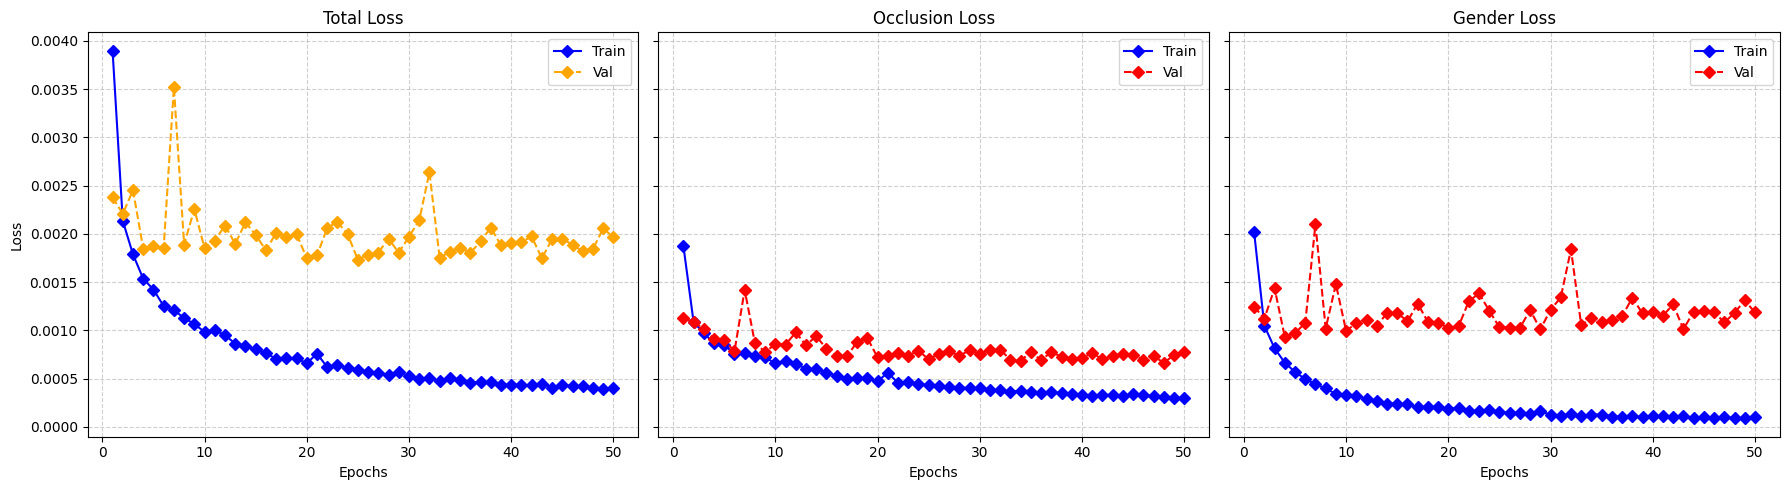

In [ ]:
# --- Retrieve data from dataframes ---

epochs =np.arange(1, len(df_train_history)+1)

gamma_gender = df_train_history['gamma_gender'][0]

print(f"gamma_gender = {gamma_gender}")

# Total
train_loss_total = df_train_history['train_loss_total'].to_numpy()
val_loss_total = df_train_history['val_loss_total'].to_numpy()

# Occlusion
train_loss_occ = df_train_history['train_loss_occ'].to_numpy()
val_loss_occ = df_train_history['val_loss_occ'].to_numpy()

# Gender
train_loss_gender = df_train_history['train_loss_gender'].to_numpy()
val_loss_gender = df_train_history['val_loss_gender'].to_numpy()

# --- Subplot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5),sharey=True)


# --- Plot 1: Total Loss ---
axes[0].plot(epochs, train_loss_total, label='Train', color='blue',marker='D')
axes[0].plot(epochs, val_loss_total, label='Val', color='orange',marker='D',linestyle='--')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# --- Plot 2: Occlusion Loss ---
axes[1].plot(epochs, train_loss_occ, label='Train', color='blue',marker='D')
axes[1].plot(epochs, val_loss_occ, label='Val', color='red',marker='D',linestyle='--')
axes[1].set_title('Occlusion Loss')
axes[1].set_xlabel('Epochs')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# --- Plot 3: Gender Loss ---
axes[2].plot(epochs, gamma_gender*train_loss_gender, label='Train', color='blue',marker='D')
#axes[2].plot(epochs, val_loss_gender, label='Val', color='brown')
axes[2].plot(epochs, gamma_gender*val_loss_gender, label='Val', color='red',marker='D',linestyle='--')
axes[2].set_title('Gender Loss')
axes[2].set_xlabel('Epochs')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

## **3. Idemia score**

best_score = 0.0013956446650304


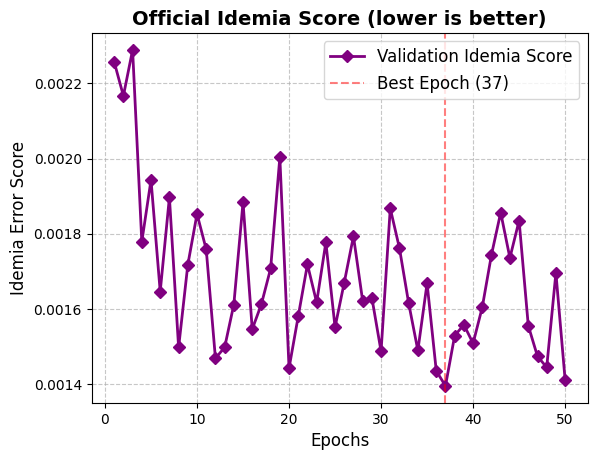

In [ ]:
idemia_score = df_train_history['idemia_val_score'].to_numpy()


plt.plot(epochs, idemia_score, label='Validation Idemia Score', color='purple', marker='D', linewidth=2)

# Highlight the best epoch
best_epoch = epochs[np.argmin(idemia_score)]
best_score = np.min(idemia_score)
print(f"best_score = {best_score}")
plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')

# Add labels and grids
plt.title('Official Idemia Score (lower is better)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Idemia Error Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Show the plot
plt.show()

## **4. Prediction distribution**

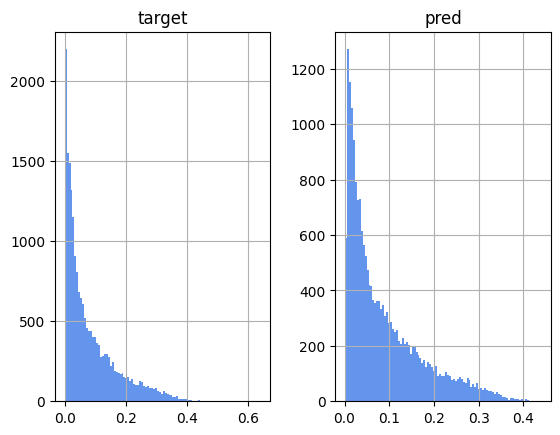

In [ ]:
# --- Histogram validation split ---
hist_occlusion = df_val_pred.hist(column = ['target','pred'], bins = 100, color='cornflowerblue')

(0.0, 1.1)

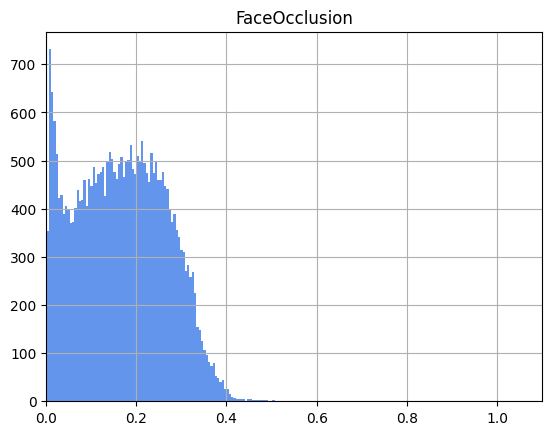

In [ ]:
# --- Histogram test split ---
hist_occlusion = df_test_pred.hist(column = ['FaceOcclusion'], bins = 100, color='cornflowerblue')
hist_occlusion[0][0].set_xlim(0, 1.1)